In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import warnings
import streamlit as st

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('data.csv', encoding='latin1')

In [ ]:
df.head()

In [ ]:
# Separate datasets
missing_cust = df['CustomerID'].isnull().sum()
total_rows = len(df)
print(f"Missing Customer IDs: {missing_cust} ({(missing_cust/total_rows)*100:.2f}% of data)")

df_customers = df.dropna(subset=['CustomerID'])  # For modeling
df_no_customers = df[df['CustomerID'].isnull()]  # For general EDA

# Convert InvoiceDate to datetime
df_customers['InvoiceDate'] = pd.to_datetime(df_customers['InvoiceDate'])

# Remove negative quantities
df_customers = df_customers[df_customers['Quantity'] > 0]

# Create TotalPrice
df_customers['TotalPrice'] = df_customers['Quantity'] * df_customers['UnitPrice']

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['UnitPrice'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Unit Price')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['Quantity'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Quantity')
plt.show()

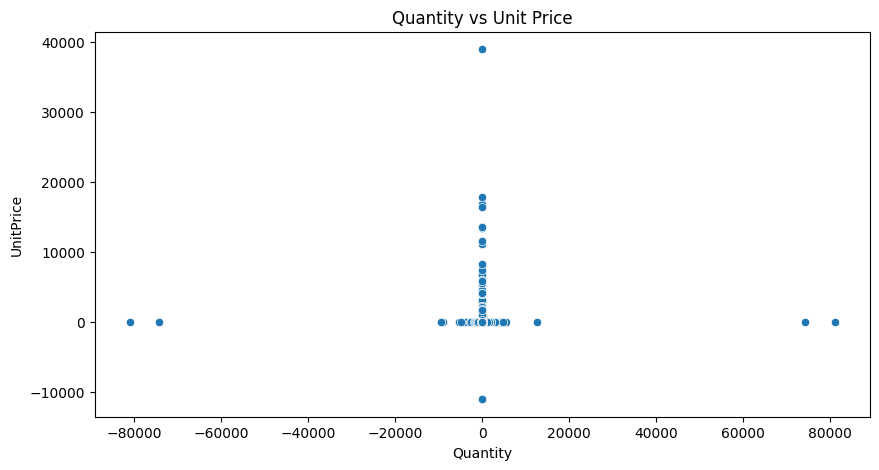

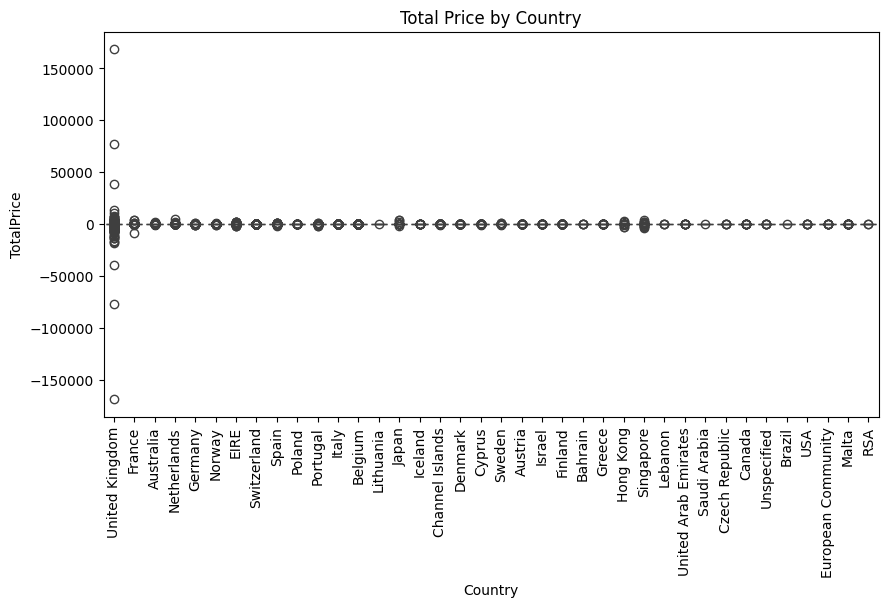

In [6]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Quantity', y='UnitPrice', data=df)
plt.title('Quantity vs Unit Price')
plt.show()

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Now plot
plt.figure(figsize=(10,5))
sns.boxplot(x='Country', y='TotalPrice', data=df)
plt.xticks(rotation=90)
plt.title('Total Price by Country')
plt.show()


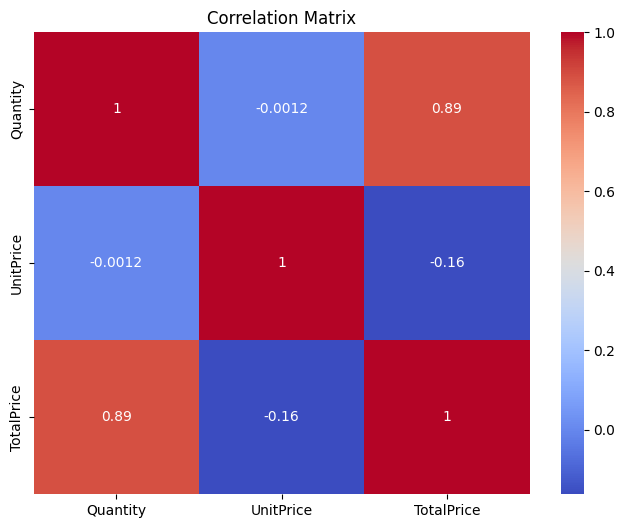

In [7]:
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [8]:
# Recency, Frequency, Monetary (RFM)
latest_date = df_customers['InvoiceDate'].max()
rfm = df_customers.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Standardize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

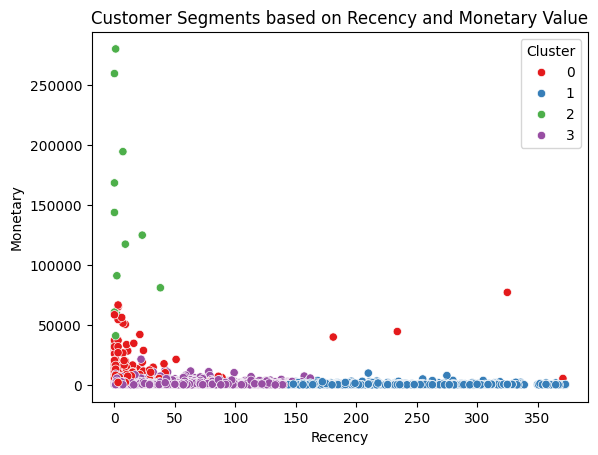

Silhouette Score: 0.62


In [9]:
# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=40)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster visualization
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='Set1')
plt.title('Customer Segments based on Recency and Monetary Value')
plt.show()

# Silhouette Score
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Silhouette Score: {score:.2f}")

In [11]:
# Create user-item matrix
pivot = df_customers.pivot_table(index='CustomerID', columns='StockCode', values='Quantity', fill_value=0)
sparse_matrix = csr_matrix(pivot)

# Cosine similarity
cos_sim = cosine_similarity(sparse_matrix)

# Function to recommend similar customers
def recommend_customers(customer_id, n_recommendations=5):
    if customer_id not in pivot.index:
        print("Customer ID not found.")
        return
    customer_idx = pivot.index.tolist().index(customer_id)
    sim_scores = list(enumerate(cos_sim[customer_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n_recommendations+1]
    customer_indices = [i[0] for i in sim_scores]
    return pivot.index[customer_indices]

# Take input from user
customer_id_input = float(input("Enter Customer ID: "))

# Get output
recommendations = recommend_customers(customer_id_input)

# Show output
print(recommendations)


Enter Customer ID:  12347.0


Index([14326.0, 12355.0, 14257.0, 13532.0, 15539.0], dtype='float64', name='CustomerID')


In [12]:
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Create user-item matrix
pivot = df_customers.pivot_table(index='CustomerID', columns='StockCode', values='Quantity', fill_value=0)

# Step 2: Create sparse matrix
sparse_matrix = csr_matrix(pivot)

# Step 3: Cosine similarity between customers
cos_sim = cosine_similarity(sparse_matrix)

# Step 4: Recommend Products
def recommend_products(customer_id, n_recommendations=5):
    if customer_id not in pivot.index:
        print("Customer ID not found.")
        return
    
    customer_idx = pivot.index.tolist().index(customer_id)
    sim_scores = list(enumerate(cos_sim[customer_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:]  # exclude the customer itself

    similar_customer_indices = [i[0] for i in sim_scores]
    similar_customers = pivot.index[similar_customer_indices]
    
    # Products the target customer has already purchased
    customer_purchases = pivot.loc[customer_id]
    purchased_products = customer_purchases[customer_purchases > 0].index.tolist()
    
    # Find products purchased by similar customers
    recommended_products = []
    for similar_customer in similar_customers:
        similar_customer_purchases = pivot.loc[similar_customer]
        products = similar_customer_purchases[similar_customer_purchases > 0].index.tolist()
        for product in products:
            if product not in purchased_products:
                recommended_products.append(product)
        if len(recommended_products) >= n_recommendations:
            break
    
    recommended_products = list(set(recommended_products))[:n_recommendations]

    # Map StockCode to Product Name
    product_mapping = df_customers[['StockCode', 'Description']].drop_duplicates().set_index('StockCode').to_dict()['Description']
    recommended_product_names = [product_mapping.get(code, "Unknown Product") for code in recommended_products]
    
    return recommended_product_names

# Take input from user
customer_id = float(input("Enter Customer ID: "))

# Get product recommendations
product_recommendations = recommend_products(customer_id)

# Show output
print("Recommended products for the customer:")
print(product_recommendations)

Enter Customer ID:  12347.0


Recommended products for the customer:
['SET/3 OCEAN SCENT CANDLE JEWEL BOX', 'ANTIQUE SILVER T-LIGHT GLASS', 'ENAMEL FLOWER JUG CREAM', 'FELTCRAFT 6 FLOWER FRIENDS', 'HANGING HEART JAR T-LIGHT HOLDER']
